#Image Classification with Linear Classifiers
In this notebook, we will work on implementing and training linear classification models. By the end, you should have gained insight into how a parametric model is structured, including:
How the loss/cost function is calculated.
How the gradient of the model’s parameters (with respect to the loss) is used to optimize the model via gradient descent.
As in Assignment 1.1, you are allowed to use tools like ChatGPT, Copilot, etc. to solve the task.


#Dataset
As with the kNN notebook, this notebook uses data from the "BloodMNIST" dataset, sourced from the [MedMNIST database](https://medmnist.com/)

#Description from the original source:
The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set.

BThe images are available in various resolutions: 28x28, 64x64, 128x128, and 224x224, with 3 channels (RGB). In this notebook, we work with images in 28x28x3 resolution. The 8 different classes are:

['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


Represented categorically with the following values:

[0, 1, 2, 3, 4, 5, 6, 7]

Below, the dataset is downloaded, imported, and split into separate training, validation (tuning), and test sets, and some examples are illustrated.

In [17]:
%pip install medmnist
import medmnist

from medmnist import BloodMNIST
trainDataset = BloodMNIST(split="train", download=True,size=28)
valDataset = BloodMNIST(split="val", download=True,size=28)
testDataset = BloodMNIST(split="test", download=True,size=28)

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.
Trainingdata:
Images: (11959, 28, 28, 3), Labels: (11959, 1)
Validation data:
Images: (1712, 28, 28, 3), Labels: (1712, 1)
Test data:
Images: (3421, 28, 28, 3), Labels: (3421, 1)


plot some examples:
Class: 0, Class name: basophil. Number of training samples: 852
Class: 1, Class name: eosinophil. Number of training samples: 2181
Class: 2, Class name: erythroblast. Number of training samples: 1085
Class: 3, Class name: immature granulocytes(myelocytes, metamyelocytes and promyelocytes). Number of training samples: 2026
Class: 4, Class name: lymphocyte. Number of training samples: 849
Class: 5, Class name: monocyte. Number of training samples: 993
Class: 6, Class name: neutrophil. Number of training samples: 2330
Class: 7, Class name: platelet. Number of training samples: 1643


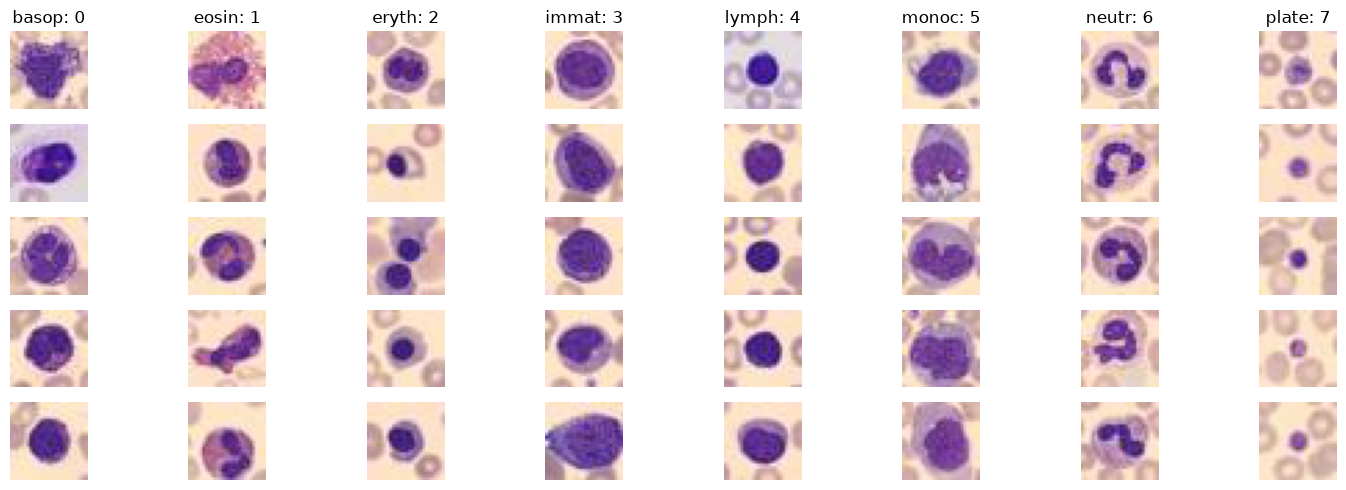

In [18]:
%pip install matplotlib
trainImages,trainLabels,trainInfo = trainDataset.__dict__['imgs'],trainDataset.__dict__['labels'],trainDataset.__dict__['info']['label']


print('Trainingdata:')
print(f'Images: {trainImages.shape}, Labels: {trainLabels.shape}')


valImages,valLabels = valDataset.__dict__['imgs'],valDataset.__dict__['labels']
print('Validation data:')
print(f'Images: {valImages.shape}, Labels: {valLabels.shape}')

testImages,testLabels = testDataset.__dict__['imgs'],testDataset.__dict__['labels']
print('Test data:')
print(f'Images: {testImages.shape}, Labels: {testLabels.shape}')

import matplotlib.pyplot as plt
import random

print('\n')
print('plot some examples:')

random.seed(42)
fig, axes = plt.subplots(5, len(trainInfo), figsize=(15, 5))

for class_,name in trainInfo.items():
    print(f'Class: {class_}, Class name: {name}. Number of training samples: {len(trainLabels[trainLabels==int(class_)])}')
    # Get indices of all images belonging to class i
    class_indices = [idx for idx, label in enumerate(trainLabels) if int(class_) == label]
    # Randomly select 5 indices
    selected_indices = random.sample(class_indices, 5)
    for j, idx in enumerate(selected_indices):
        image, label = trainImages[idx],trainLabels[idx]
        axes[j, int(class_)].imshow(image, cmap='gray')
        axes[j, int(class_)].axis('off')
        if j == 0:
            axes[j, int(class_)].set_title(f'{name[:5]}: {class_}')

plt.tight_layout()
plt.show()

In [19]:
import numpy as np

#set random seed for reproducibility
np.random.seed(0)

#Shuffle the data
randomize = np.arange(trainImages.shape[0])
np.random.shuffle(randomize)

X_train = trainImages[randomize]
y_train = trainLabels[randomize].flatten()

randomizeVal = np.arange(valImages.shape[0])
X_val = valImages[randomizeVal]
y_val = valLabels[randomizeVal].flatten()


# Subsample the data for more efficient code execution in this exercise
num_training = 5000
mask = list(range(num_training))

X_train = X_train[mask]
y_train = y_train[mask]

print('first 10 examples in train: ',y_train[:10])

num_val = 500
mask = list(range(num_val))
X_val = X_val[mask]
y_val = y_val[mask]

print('first 10 examples in val: ',y_val[:10])

# Reshape the image data into rows for effecient distance calculation
#(We take the image with dimensions 28x28x3 and flatten it into a vector with a length of 28 × 28 × 3 = 2352.)
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
print(f'New train shape: {X_train.shape}')
print(f'New val shape: {X_val.shape}')


first 10 examples in train:  [1 0 2 7 7 4 3 0 4 7]
first 10 examples in val:  [4 0 7 6 1 6 1 7 6 5]
New train shape: (5000, 2352)
New val shape: (500, 2352)


[230.0064 199.1086 185.6402 230.0196 199.0904 185.7078 229.8808 199.2164
 185.9048 230.2784]


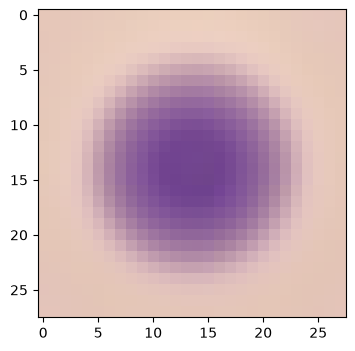

-194.6206 173.8098
(5000, 2353) (500, 2353)


In [20]:
# Preprocessing: subtract the mean image
# first: compute the image mean based on the training data
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) # print a few of the elements
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((28,28,3)).astype('uint8')) # visualize the mean image
plt.show()

# second: subtract the mean image from train and test data
X_train = X_train.astype(np.float32)-mean_image
X_val = X_val.astype(np.float32)-mean_image

print(X_train.min(),X_train.max())

# third: append the bias dimension of ones (i.e. bias trick) so that our SVM
# only has to worry about optimizing a single weight matrix W.
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])

print(X_train.shape, X_val.shape)

##Standadizing data
You could consider standardizing you data, e.g divide by 255 to get it on a scale from [-1,1]. This may help to avoid exploding gradients since the current values of the input data are quite large.

#Implementation of SVM/Hinge-loss
Below, implement a function to for calculating the hinge loss based on an image/set of images and associated class/label

In [21]:
#################################################
#generate a random SVM weight matrix of small
#numbers corresponding to image size (+ bias dimension)
#depth of num classes
##################################################
image_size = 28*28*3+1
num_classes = 8

W = np.random.randn(image_size, num_classes) * 0.0001

###################################################
#The function should accept The W weight-/parameter
#matrix along with an image/batch of images as input
#and return the loss for the
#image/batch based on the claculated scores
#The l2 regularization loss should also be included
#in the function's claculation.
#In order to check the implementation, try to claculate
#the loss but with, and without regularization.
#For the hinge/svm loss, the expected loss from random
#initialized wieghts ~= k-1 where k is number of classes
####################################################

def svm_loss(W, X, y, reg=0):
    # Beregner en score for hver klasse
    scores = X @ W

    # Finder scoren for den korrekte klasse for hvert billede
    correct_scores = scores[np.arange(X.shape[0]), y]

    # Beregner hvor meget de forkerte klasser skal straffes
    margins = np.maximum(0, scores - correct_scores[:, np.newaxis] + 1
    )

    # Den korrekte klasse skal ikke give loss
    margins[np.arange(X.shape[0]), y] = 0

    # Beregner den gennemsnitlige loss
    loss = np.sum(margins) / X.shape[0]

    # Tilføjer L2 regularization
    loss += reg * np.sum(W * W)

    # Finder de klasser som faktisk gav loss
    mask = (margins > 0).astype(float)

    # Den korrekte klasse skal trækkes i den modsatte retning
    mask[np.arange(X.shape[0]), y] = -np.sum(mask, axis=1)

    # Beregner hvordan weights skal ændres
    grad = X.T @ mask
    grad /= X.shape[0]

    # Regularization påvirker også gradienten
    grad += 2 * reg * W

    return loss, grad




#Test the loss using the validation set

E.g.:

    loss = svm_loss(W,X,y,reg):

In [22]:
#Test the loss with and without regularization using the validation set
#With regularization the loss should increase.
#test with large value. e.g. 1e3 to make sure

## '_' betyder, at der kommer endnu en værdi, men vi bruger den ikke. Vi kan derfor bruge '_' til at ignorere den værdi.
## Det er 'grad' fra kodeblokken ovenover vi ikke bruger.
## loss uden regularisering
loss_without_reg, _ = svm_loss(W, X_val, y_val, reg=0)

## loss med høj regularisering
loss_with_reg, _ = svm_loss(W, X_val, y_val, reg=1e3)

print(f"Loss without regularization: {loss_without_reg:.4f}")
print(f"Loss with regularization: {loss_with_reg:.4f}")


Loss without regularization: 6.8478
Loss with regularization: 7.0324


#Compute the gradients of the weights with respect to the loss
In order to optimize the classifier we need to compute gradients for the weight matrix so the loss can be minimized. It is would be a good idea to include the gradient calculation in the loss function defined above such that scores, loss and gradient can be calculated at the same time using the function.

E.g.:

    loss,grad = svm_loss(W,X,y,reg)


The gradients are a matrix with the same shape a W. The regularization should also affect the gradient so make sure this is included in the computation




In [23]:
###################################################
#Once the implementation is complete try to print the
#shape of the gradient matrix as well as the first row
#It should return something similar to this:
# [-3.0962016  4.9891232 -4.0875872  0.8926112  1.0465696 -1.5291232
#  3.9497376 -2.1651296]
#####################################################

# Beregner loss og gradient
loss, grad = svm_loss(W, X_val, y_val, reg=0)

# Tjekker at gradienten har samme størrelse som W
print("W shape:", W.shape)
print("Gradient shape:", grad.shape)

# Viser den første række af gradienten
print("First row of gradient:")
print(grad[0])


W shape: (2353, 8)
Gradient shape: (2353, 8)
First row of gradient:
[-3.0962016  4.9891232 -4.0875872  0.8926112  1.0465696 -1.5291232
  3.9497376 -2.1651296]


#Implementation of Softmax-loss
Below, repeat the steps from above but for the softmax loss/gradient instead

In [24]:
def softmax_loss(W, X, y, reg=0):
    # Beregner en score for hver klasse
    scores = X @ W

    # Gør beregningen mere stabil
    scores -= np.max(scores, axis=1, keepdims=True)

    # Laver scores om til sandsynligheder
    exp_scores = np.exp(scores)
    probabilities = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    # Finder sandsynligheden for den korrekte klasse
    correct_probabilities = probabilities[np.arange(X.shape[0]), y]

    # Beregner den gennemsnitlige loss
    loss = -np.mean(np.log(correct_probabilities))

    # Tilføjer L2 regularization
    loss += reg * np.sum(W * W)

    # Beregner gradienten
    dscores = probabilities.copy()
    dscores[np.arange(X.shape[0]), y] -= 1
    dscores /= X.shape[0]

    grad = X.T @ dscores

    # Regularization påvirker også gradienten
    grad += 2 * reg * W

    return loss, grad

Test the loss and gradient calculations

E.g.:

    loss,grad = softmax_loss(W,X,y,reg)

The loss with an randomly initialized weight matrix should be ~ -ln(1/k) where k=number of classes

In [25]:
###################################################
#Once the implementation is complete try to print the
#loss, shape of the gradient matrix as well as the first row
#The gradient claculation should return something similar to this:
# [-0.36533844  0.69120216 -0.47791155  0.10853622  0.05629067 -0.23380291
#  0.50159745 -0.2805736 ]
#####################################################

# Beregner Softmax loss og gradient
loss, grad = softmax_loss(W, X_val, y_val, reg=0)

# Viser loss
print(f"Softmax loss: {loss:.4f}")

# Tjekker gradienten
print("Gradient shape:", grad.shape)

# Viser den første række af gradienten
print("First row of gradient:")
print(grad[0])

Softmax loss: 2.0694
Gradient shape: (2353, 8)
First row of gradient:
[-0.38525238  0.65388555 -0.50230434  0.06259369  0.16268658 -0.11673126
  0.40334411 -0.27822195]


#Implementation of linear classifier

The implementation of the linear classifier should be constructed as a class that initializes a weight matrix based on the shape of the input and number of classes and type of loss computed (SVM/Softmax). It should have methods for training (updating the weights) and inference (predicting classes from scores).

Note!

The training function should propably have a "batch_size" parameter such that training data is iterated in batches so as to not run out of memory. Use np.array_split to divide data into n batches of "batch_size".

psuedo code example:


    class LinearClassifier:
      def __init__(self, input_dim, num_classes, loss_type='softmax'):

          self.W = np.random.randn(input_dim, num_classes) * 0.01
          self.loss_type = loss_type

          method train()

          method softmax_loss()

          method svm_loss()

          method predict()

In [26]:

##################################
# Implement linear classifier class
##################################
class LinearClassifier:
    def __init__(self, input_dim, num_classes, loss_type="softmax"):
        # Laver en vægtmatrix med små tilfældige værdier
        self.W = np.random.randn(input_dim, num_classes) * 0.0001

        # Gemmer om modellen skal bruge SVM eller Softmax
        self.loss_type = loss_type

    def svm_loss(self, X, y, reg=0):
        # Beregner SVM loss og gradient med modellens weights
        return svm_loss(self.W, X, y, reg)

    def softmax_loss(self, X, y, reg=0):
        # Beregner Softmax loss og gradient med modellens weights
        return softmax_loss(self.W, X, y, reg)

    def train(self, X, y, learning_rate=1e-6, reg=0, num_iters=1000, batch_size=200):
        # Gemmer loss under træningen, så vi senere kan plotte den
        loss_history = []

        # Beregner hvor mange batches datasættet skal deles op i
        num_batches = int(np.ceil(X.shape[0] / batch_size))

        iteration = 0

        while iteration < num_iters:
            # Blander rækkefølgen af billederne
            indices = np.random.permutation(X.shape[0])

            # Deler billedernes indices op i batches
            batches = np.array_split(indices, num_batches)

            for batch_indices in batches:
                # Henter billeder og labels til den aktuelle batch
                X_batch = X[batch_indices]
                y_batch = y[batch_indices]

                # Beregner loss og gradient ud fra den valgte loss-type
                if self.loss_type == "svm":
                    loss, grad = self.svm_loss(X_batch, y_batch, reg)
                else:
                    loss, grad = self.softmax_loss(X_batch, y_batch, reg)

                # Opdaterer weights i den retning der mindsker loss
                self.W -= learning_rate * grad

                # Gemmer loss fra denne iteration
                loss_history.append(loss)

                iteration += 1

                # Stopper når det ønskede antal iterationer er nået
                if iteration >= num_iters:
                    break

        return loss_history
    
    def predict(self, X):
        # Beregner en score for hver klasse
        scores = X @ self.W

        # Vælger den klasse der har den højeste score
        predictions = np.argmax(scores, axis=1)

        return predictions

#Train the classifier once on the training set
It might be a good idea to have the training function of you model return a "history" or similar object holding the values of the loss at each m steps of the training. Afterwards the history object (for instance a list) can be plottet to visualize how training progressed.

Calling the training function would thus look something like this:

    classifier = LinearClassifier(input_dim=28*28*3+1,num_classes=8, loss_type='svm')

    history = classifier.train(params)

    plot(history)

    #make predictions on the validation data
    pred = classifier.predict(X)

    #calculate the accuracy

In [27]:
##########################################
#Train the classifier and plot the results
##########################################

# Laver en SVM classifier
classifier = LinearClassifier(
    input_dim=28*28*3+1,
    num_classes=8,
    loss_type="svm"
)

# Træner modellen og gemmer loss fra hver iteration
history = classifier.train(
    X_train,
    y_train,
    learning_rate=1e-6,
    reg=1e-2,
    num_iters=1000,
    batch_size=200
)

#Optimize SVM classifier
We start by optimizing the the classifier with the svm loss function.

Using the training and validation sets run training loops with different setting for learning rate and regularization strength. For each setting, iterate over the training set n times updating the weight matrix based on the gradients and evaluate performance on the validation set every m iterations. Save the best classifier object in a variable "best_svm".


E.g.

    best_svm = None
    best_accuracy = 0

    # These values are only given as examples. In your own loop
    # you should test more in order to optimize the classifier

    learning_rates = [1e-2,1e-4,1e-6]
    regularization_strenghts = [1,1e-2,1e-1,1e2]

    num_iters = 1000
    batch_size = 200

    for lr in learning_rates:
      for reg in regularizations_strenghts:

        svm = LinearClassifier(input_dim=28*28*3+1,num_classes=8,loss_type='svm')

        svm.train(params)

        pred = svm.predict(X)

        #calculate accuracy

        
        if accuracy > best_accuracy:
          best_svm = svm
          best_accuracy = accuracy


! It may take a long time for the model to converge. Therefor, the hyperparameter search in this notebook could be used to identify a reasonable set of hyperparameters and then the model should be trained for longer using these. Using the full training dataset to maximize performance
        


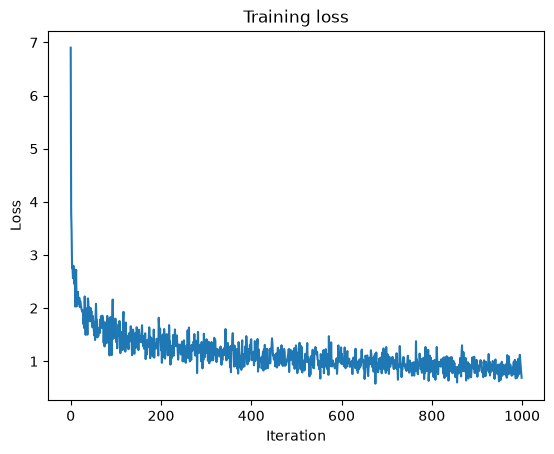

Validation accuracy: 77.60%
lr=0.0001, reg=1, accuracy=74.40%
lr=0.0001, reg=0.1, accuracy=77.60%
lr=0.0001, reg=0.01, accuracy=75.20%
lr=1e-05, reg=1, accuracy=78.80%
lr=1e-05, reg=0.1, accuracy=80.20%
lr=1e-05, reg=0.01, accuracy=79.80%
lr=1e-06, reg=1, accuracy=77.80%
lr=1e-06, reg=0.1, accuracy=77.40%
lr=1e-06, reg=0.01, accuracy=78.20%


In [33]:
###########################
#Put optimization code here
###########################

# Plotter hvordan loss udvikler sig under træningen
plt.plot(history)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

# Laver predictions på validation-sættet
predictions = classifier.predict(X_val)

# Beregner hvor stor en andel modellen klassificerer korrekt
accuracy = np.mean(predictions == y_val)

print(f"Validation accuracy: {accuracy * 100:.2f}%")

# Gemmer den bedste SVM-model og dens accuracy
best_svm = None
best_accuracy = 0

# Værdier vi vil teste
learning_rates = [1e-4, 1e-5, 1e-6]
regularization_strengths = [1, 1e-1, 1e-2]

# Træningsindstillinger
num_iters = 1000
batch_size = 200

# Tester alle kombinationer af learning rate og regularization
for lr in learning_rates:
    for reg in regularization_strengths:

        # Laver en ny SVM-classifier for hver kombination
        svm = LinearClassifier(
            input_dim=28*28*3+1,
            num_classes=8,
            loss_type="svm"
        )

        # Træner modellen med de aktuelle værdier
        history = svm.train(
            X_train,
            y_train,
            learning_rate=lr,
            reg=reg,
            num_iters=num_iters,
            batch_size=batch_size
        )

        # Laver predictions på validation-sættet
        predictions = svm.predict(X_val)

        # Beregner validation accuracy
        accuracy = np.mean(predictions == y_val)

        # Viser resultatet for denne kombination
        print(
            f"lr={lr}, reg={reg}, "
            f"accuracy={accuracy * 100:.2f}%"
        )

        # Gemmer modellen hvis den er bedre end den bedste hidtil
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_svm = svm

I could be a good idea to record as much informartion as possible from the optimization. E.g. loss as function of hyperparameters. This can be used for visualizing results of the tuning and included in the assignment 1 report.

#visualize the weights
Depending on how you implemented the classifier it is possible to visualize the learned weights. I the classifier is well optimized you may notice the sort of class templates encoded in the weight matrix.



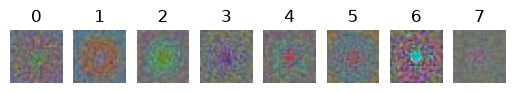

In [34]:
 #Visualization of learned weights. This may or may not work depending on how your classifier is implemented.
w = best_svm.W[:-1,:] # strip out the bias
w = w.reshape(28, 28, 3, 8)
w_min, w_max = np.min(w), np.max(w)
classes = ['0', '1', '2', '3', '4', '5', '6', '7']
for i in range(8):
    plt.subplot(1, 8, i + 1)

    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])



You can compare the learned weights to a set of randomly initialized weights

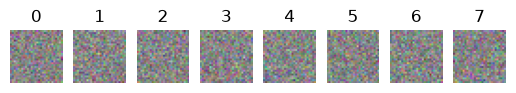

In [35]:
#Compare the trained weights to a set of random initialized weights
w = np.random.randn(28*28*3+1, num_classes) * 0.001
w = w[:-1,:] # strip out the bias
w = w.reshape(28, 28, 3, 8)
w_min, w_max = np.min(w), np.max(w)
classes = ['0', '1', '2', '3', '4', '5', '6', '7']
for i in range(8):
    plt.subplot(1, 8, i + 1)

    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])

#Optimize softmax classifier
Repeat the steps above but using the linear classifier with softmax loss. Report results for both in assignment 1

In the hand-in for assignment 1 you should be able to explain the implementation of the loss and gradients for the two types of linear classifiers. Therefore it might be good to include relevant code snippets.

The Hand in should include the tuning results/graphs (train and validation to discuss overfitting potential) and test set results think about metrics that make sense to calculate and include. E.g confusion matrix.

In [36]:
## Optimization of softmax classifier 

# Gemmer den bedste Softmax-model og dens accuracy
best_softmax = None
best_accuracy = 0

# Værdier vi vil teste
learning_rates = [1e-4, 1e-5, 1e-6]
regularization_strengths = [1, 1e-1, 1e-2]

# Træningsindstillinger
num_iters = 1000
batch_size = 200


# Tester alle kombinationer af learning rate og regularization
for lr in learning_rates:
    for reg in regularization_strengths:

        # Laver en ny Softmax-classifier for hver kombination
        softmax = LinearClassifier(
            input_dim=28*28*3+1,
            num_classes=8,
            loss_type="softmax"
        )

        # Træner modellen med de aktuelle værdier
        history = softmax.train(
            X_train,
            y_train,
            learning_rate=lr,
            reg=reg,
            num_iters=num_iters,
            batch_size=batch_size
        )

        # Laver predictions på validation-sættet
        predictions = softmax.predict(X_val)

        # Beregner validation accuracy
        accuracy = np.mean(predictions == y_val)

        # Viser resultatet for denne kombination
        print(
            f"lr={lr}, reg={reg}, "
            f"accuracy={accuracy * 100:.2f}%"
        )

        # Gemmer modellen hvis den er bedre end den bedste hidtil
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_softmax = softmax

lr=0.0001, reg=1, accuracy=77.40%
lr=0.0001, reg=0.1, accuracy=72.20%
lr=0.0001, reg=0.01, accuracy=75.20%
lr=1e-05, reg=1, accuracy=80.20%
lr=1e-05, reg=0.1, accuracy=79.20%
lr=1e-05, reg=0.01, accuracy=80.00%
lr=1e-06, reg=1, accuracy=74.00%
lr=1e-06, reg=0.1, accuracy=73.20%
lr=1e-06, reg=0.01, accuracy=74.80%
